# Dual-Encoder Sensor-Fusion LSTM-AE 재현 실험

이 notebook은 독립적인 통제 실험입니다. 기준 notebook의 데이터 로딩, 절대값 변환, MinMax scaling, window 구성, train/validation/test split, 이후 anomaly score 산출 규칙을 그대로 유지합니다. 이후 단계에서 encoder 구조만 변경합니다.

기준: `../../pytorch_reproduction.ipynb`. 고정 규칙: `EXPERIMENT_CONTRACT.md`.

## 1. 실행 환경과 고정 설정

다음 셀은 notebook kernel의 시작 위치를 가정하지 않고 프로젝트 root를 찾습니다. 또한 원본 CSV를 이 실험 폴더로 복사하지 않은 상태에서 파일 존재 여부를 검증합니다.

In [1]:
from pathlib import Path
import sys

def find_project_root(start=None):
    candidate = (Path.cwd() if start is None else Path(start)).resolve()
    if candidate.is_file():
        candidate = candidate.parent
    for directory in (candidate, *candidate.parents):
        if (directory / 'data').is_dir() and (directory / 'experiment' / 'sensor_fusion').is_dir():
            return directory
    raise FileNotFoundError(
        "프로젝트 root를 찾지 못했습니다. clone한 ManufactorAIContest 저장소 내부에서 notebook을 실행하세요."
    )

PROJECT_ROOT = find_project_root()
SENSOR_FUSION_DIR = PROJECT_ROOT / 'experiment' / 'sensor_fusion'
if str(SENSOR_FUSION_DIR) not in sys.path:
    sys.path.insert(0, str(SENSOR_FUSION_DIR))

from experiment_config import (
    CURRENT_FEATURES, FEATURES, NORMAL_FILENAME, OUTLIER_FILENAME,
    VIBRATION_FEATURES, ExperimentConfig, config_dict, resolve_data_paths,
)

cfg = ExperimentConfig()
NORMAL_PATH, OUTLIER_PATH = resolve_data_paths(PROJECT_ROOT)
RESULTS_ROOT = SENSOR_FUSION_DIR / 'results'
RUN_ID = 'dual_encoder_run01'  # 완료된 실행 결과를 덮어쓰지 않도록 필요한 경우에만 변경합니다.
OUTPUT_DIR = RESULTS_ROOT / RUN_ID

print(f'프로젝트 root: {PROJECT_ROOT}')
print(f'정상 CSV:       {NORMAL_PATH}')
print(f'이상 CSV:       {OUTLIER_PATH}')
print(f'결과 폴더:      {OUTPUT_DIR}')
print('고정 설정:', config_dict())
print('진동 branch:', VIBRATION_FEATURES)
print('전류 branch:', CURRENT_FEATURES)

프로젝트 root: E:\ManufactorAIContest
정상 CSV:       E:\ManufactorAIContest\data\press_data_normal.csv
이상 CSV:       E:\ManufactorAIContest\data\outlier_data.csv
결과 폴더:      E:\ManufactorAIContest\sensor_fusion\results\dual_encoder_run01
고정 설정: {'sequence': 20, 'label_offset': 100, 'train_rows': 15000, 'valid_normal': 880, 'valid_anomaly': 300, 'epochs': 800, 'batch_size': 128, 'learning_rate': 0.001, 'lr_factor': 0.7, 'lr_patience': 50, 'es_min_delta': 1e-05, 'es_patience': 120, 'seed': 42}
진동 branch: ('AI0_Vibration', 'AI1_Vibration')
전류 branch: ('AI2_Current',)


## 2. import와 재현성 설정

seed와 패키지 선택은 PyTorch 기준 notebook을 따릅니다. 아래 데이터 파이프라인에는 modality별 변경이 없습니다. 최종 배열에서도 세 채널의 원래 순서를 유지합니다.

In [2]:
import json
import random

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

random.seed(cfg.seed)
np.random.seed(cfg.seed)

def save_json(path, data):
    def convert(value):
        if isinstance(value, np.ndarray):
            return value.tolist()
        if isinstance(value, np.generic):
            return value.item()
        if isinstance(value, Path):
            return str(value)
        raise TypeError(type(value).__name__)
    Path(path).write_text(
        json.dumps(data, ensure_ascii=False, indent=2, default=convert), encoding='utf-8'
    )

if (OUTPUT_DIR / 'metrics.json').exists():
    raise FileExistsError(f'RUN_ID={RUN_ID}에 완료된 결과가 이미 있습니다. 새 RUN_ID를 지정하세요.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
save_json(OUTPUT_DIR / 'config.json', config_dict())

## 3. 기준과 동일한 데이터 로딩 및 검증

기준 notebook의 13번 cell과 같은 규칙입니다. 결측값, 비유한값, 예상과 다른 컬럼·행 수·label을 임의로 정리하거나 변경하지 않고 오류로 처리합니다.

In [3]:
EXPECTED_COLUMNS = ['TimeStamp', *FEATURES, 'Equipment_state']

def load_data(normal_path, outlier_path):
    normal = pd.read_csv(normal_path, index_col=0)
    outlier = pd.read_csv(outlier_path, index_col=0)
    for name, frame, rows, state in [
        ('normal', normal, 20000, 0),
        ('outlier', outlier, 600, 1),
    ]:
        if list(frame.columns) != EXPECTED_COLUMNS:
            raise ValueError(f'{name} 데이터의 컬럼이 예상과 다릅니다: {list(frame.columns)}')
        if len(frame) != rows or not frame.Equipment_state.eq(state).all():
            raise ValueError(f'{name} 데이터의 행 수 또는 label이 예상과 다릅니다')
        if frame.isna().any().any() or not np.isfinite(frame[list(FEATURES)].to_numpy()).all():
            raise ValueError(f'{name} 데이터에 결측값 또는 비유한값이 있습니다. 기준 데이터를 임의로 변경하지 마세요.')
    return normal, outlier

normal, outlier = load_data(NORMAL_PATH, OUTLIER_PATH)
print('normal shape:', normal.shape, 'label 분포:', normal.Equipment_state.value_counts().to_dict())
print('outlier shape:', outlier.shape, 'label 분포:', outlier.Equipment_state.value_counts().to_dict())
display(normal.head())
display(outlier.head())

normal shape: (20000, 5) label 분포: {0: 20000}
outlier shape: (600, 5) label 분포: {1: 600}


,TimeStamp,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
0,2022-07-12 00:00:00.019,0.116967,-0.176403,192.338730,0
1,2022-07-12 00:00:00.119,0.030080,-0.210895,217.004330,0
2,2022-07-12 00:00:00.219,-0.045794,-0.029424,197.510620,0
3,2022-07-12 00:00:00.319,0.047519,0.258642,156.607170,0
4,2022-07-12 00:00:00.419,0.020351,0.173777,93.236934,0


,TimeStamp,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
0,2022-07-17 10:51:07.943,0.293727,-0.540554,21.457675,1
1,2022-07-17 10:51:08.043,1.070320,-0.557382,-44.107442,1
2,2022-07-17 10:51:08.143,0.908692,0.063108,25.033954,1
3,2022-07-17 10:51:08.243,0.235921,0.509321,-101.327910,1
4,2022-07-17 10:51:16.724,0.315538,0.205315,34.570698,1


## 4. 고정된 scaling, window 구성, 시간순 split

이 단계에서는 채널을 분리하거나 순서를 바꾸지 않습니다. dual encoder는 model의 `forward` 내부에서만 결과 `(batch, sequence, 3)` tensor를 분기별로 slice합니다.

In [4]:
def make_windows(x, y, sequence, offset):
    windows, labels = [], []
    for index in range(len(x) - sequence - offset):
        windows.append(x[index:index + sequence])
        labels.append(y[index + sequence + offset])
    return np.array(windows), np.array(labels)

def prepare(normal, outlier, cfg):
    # 기준 notebook 15번 cell: 모든 feature에 대해 절대값 변환이 scaling보다 앞섭니다.
    normal_data, outlier_data = normal.copy(), outlier.copy()
    normal_data[list(FEATURES)] = normal_data[list(FEATURES)].applymap(abs)
    outlier_data[list(FEATURES)] = outlier_data[list(FEATURES)].applymap(abs)

    scaler = MinMaxScaler()
    train = scaler.fit_transform(normal_data[list(FEATURES)][:cfg.train_rows])
    test_normal = scaler.transform(normal_data[list(FEATURES)][cfg.train_rows:])
    test_anomaly = scaler.transform(outlier_data[list(FEATURES)])

    x_train, y_train = make_windows(
        train, normal_data.Equipment_state.to_numpy()[:cfg.train_rows], cfg.sequence, cfg.label_offset
    )
    xn, yn = make_windows(
        test_normal, normal_data.Equipment_state.to_numpy()[cfg.train_rows:], cfg.sequence, cfg.label_offset
    )
    xa, ya = make_windows(
        test_anomaly, outlier_data.Equipment_state.to_numpy(), cfg.sequence, cfg.label_offset
    )

    x_valid = np.vstack((xn[:cfg.valid_normal], xa[:cfg.valid_anomaly]))
    y_valid = np.hstack((yn[:cfg.valid_normal], ya[:cfg.valid_anomaly]))
    x_test = np.vstack((xn[cfg.valid_normal:], xa[cfg.valid_anomaly:]))
    y_test = np.hstack((yn[cfg.valid_normal:], ya[cfg.valid_anomaly:]))
    data = {
        'X_train': x_train, 'Y_train': y_train,
        'X_valid': x_valid, 'Y_valid': y_valid,
        'X_test': x_test, 'Y_test': y_test,
        'X_valid_0': x_valid[y_valid == 0], 'scaler': scaler,
    }

    expected = {
        'X_train': (14880, 20, 3), 'X_valid': (1180, 20, 3),
        'X_test': (4180, 20, 3), 'X_valid_0': (880, 20, 3),
    }
    if (cfg.sequence, cfg.label_offset, cfg.train_rows, cfg.valid_normal, cfg.valid_anomaly) == (20, 100, 15000, 880, 300):
        for key, shape in expected.items():
            assert data[key].shape == shape, (key, data[key].shape, shape)
        assert np.array_equal(np.bincount(y_valid), [880, 300])
        assert np.array_equal(np.bincount(y_test), [4000, 180])
    return data

data = prepare(normal, outlier, cfg)
shapes = {key: value.shape for key, value in data.items() if isinstance(value, np.ndarray)}
display(pd.DataFrame(shapes.items(), columns=['tensor', 'shape']))
print('Validation label 분포:', np.bincount(data['Y_valid']))
print('Test label 분포:', np.bincount(data['Y_test']))

,tensor,shape
0,X_train,"(14880, 20, 3)"
1,Y_train,"(14880,)"
2,X_valid,"(1180, 20, 3)"
3,Y_valid,"(1180,)"
4,X_test,"(4180, 20, 3)"
5,Y_test,"(4180,)"
6,X_valid_0,"(880, 20, 3)"


Validation label 분포: [880 300]
Test label 분포: [4000  180]


## 5. 검증 가능한 split manifest

manifest는 원본 input과 label의 행 위치·시간을 보존합니다. 기준 notebook과 동일하게 guidebook의 label-offset overlap을 명시적으로 남기지만 split 자체는 변경하지 않습니다.

In [5]:
def split_manifest(normal, outlier, cfg):
    frames = []
    for source, frame, start, count, valid_count in [
        ('normal_train', normal, 0, cfg.train_rows - cfg.sequence - cfg.label_offset, 0),
        ('normal', normal, cfg.train_rows, len(normal) - cfg.train_rows - cfg.sequence - cfg.label_offset, cfg.valid_normal),
        ('anomaly', outlier, 0, len(outlier) - cfg.sequence - cfg.label_offset, cfg.valid_anomaly),
    ]:
        for index in range(count):
            first = start + index
            last = start + index + cfg.sequence - 1
            label = start + index + cfg.sequence + cfg.label_offset
            frames.append({
                'split': 'train' if source == 'normal_train' else ('valid' if index < valid_count else 'test'),
                'source': 'normal' if source == 'normal_train' else source,
                'input_start_row': first, 'input_end_row': last, 'label_row': label,
                'input_end_time': frame.iloc[last].TimeStamp,
                'label_time': frame.iloc[label].TimeStamp,
                'label': int(frame.iloc[label].Equipment_state),
            })
    return pd.DataFrame(frames)

manifest = split_manifest(normal, outlier, cfg)
assert manifest.groupby(['split', 'label']).size().to_dict() == {
    ('test', 0): 4000, ('test', 1): 180, ('train', 0): 14880,
    ('valid', 0): 880, ('valid', 1): 300,
}
manifest.to_csv(OUTPUT_DIR / 'split_manifest.csv', index=False, encoding='utf-8-sig')
joblib.dump(data['scaler'], OUTPUT_DIR / 'scaler.joblib')
save_json(OUTPUT_DIR / 'split_shapes.json', {key: list(value) for key, value in shapes.items()})
display(manifest.groupby(['split', 'label']).size().unstack(fill_value=0))
print('기준과 동일한 데이터 파이프라인 assertion을 통과했습니다.')

label,0,1
split,,
test,4000,180
train,14880,0
valid,880,300


기준과 동일한 데이터 파이프라인 assertion을 통과했습니다.


## 6. 이중 encoder sensor-fusion LSTM-AE

기준 `LSTMAutoencoder`와 비교해 변경하는 구조는 encoder뿐입니다. 진동 branch는 `2 → 64 → 16`, 전류 branch는 `1 → 32 → 16`입니다. 두 vector를 concatenate해 만든 32차원 fused latent를 기준과 같은 `32 → 32 → 64 → 3` decoder에 전달합니다. attention, gating, fusion loss, 추가 feature engineering은 사용하지 않습니다.

16 + 16 분할은 기준 모델의 32차원 decoder 입력을 유지하기 위한 사전 구조 선택입니다. validation이나 test 결과를 보고 선택한 값이 아닙니다.

In [6]:
import torch
from torch import nn

torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('모델 실행 device:', device)

def initialize_keras_compatible_lstm(layer):
    """기준 notebook의 LSTM 초기화 방식을 적용합니다."""
    nn.init.xavier_uniform_(layer.weight_ih_l0)
    nn.init.orthogonal_(layer.weight_hh_l0)
    nn.init.zeros_(layer.bias_ih_l0)
    with torch.no_grad():
        layer.bias_ih_l0[layer.hidden_size:2 * layer.hidden_size].fill_(1)
    nn.init.zeros_(layer.bias_hh_l0)
    layer.bias_hh_l0.requires_grad_(False)

class DualEncoderSensorFusionLSTMAutoencoder(nn.Module):
    """진동/전류 LSTM encoder를 분리하고 latent를 단순 concatenate합니다."""

    def __init__(self, sequence):
        super().__init__()
        self.sequence = sequence
        # 진동 branch: AI0_Vibration, AI1_Vibration
        self.vibration_encoder1 = nn.LSTM(2, 64, batch_first=True)
        self.vibration_encoder2 = nn.LSTM(64, 16, batch_first=True)
        # 전류 branch: AI2_Current
        self.current_encoder1 = nn.LSTM(1, 32, batch_first=True)
        self.current_encoder2 = nn.LSTM(32, 16, batch_first=True)
        # 진동 16차원 + 전류 16차원이며 decoder 차원은 기준 모델과 같습니다.
        self.decoder1 = nn.LSTM(32, 32, batch_first=True)
        self.decoder2 = nn.LSTM(32, 64, batch_first=True)
        self.output = nn.Linear(64, 3)
        for layer in (
            self.vibration_encoder1, self.vibration_encoder2,
            self.current_encoder1, self.current_encoder2,
            self.decoder1, self.decoder2,
        ):
            initialize_keras_compatible_lstm(layer)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def _fused_latent(self, x):
        if x.ndim != 3 or x.shape[1] != self.sequence or x.shape[2] != 3:
            raise ValueError(f'(batch, {self.sequence}, 3) 형식을 기대했지만 {tuple(x.shape)}을 받았습니다')
        vibration, _ = self.vibration_encoder1(x[:, :, :2])
        _, (vibration_hidden, _) = self.vibration_encoder2(vibration)
        current, _ = self.current_encoder1(x[:, :, 2:])
        _, (current_hidden, _) = self.current_encoder2(current)
        return torch.cat((vibration_hidden[-1], current_hidden[-1]), dim=1)

    def encode(self, x):
        """32차원 fused latent를 반환합니다. anomaly score 계산에는 사용하지 않습니다."""
        return self._fused_latent(x)

    def forward(self, x):
        fused_latent = self._fused_latent(x)
        decoded = fused_latent.unsqueeze(1).repeat(1, self.sequence, 1)
        decoded, _ = self.decoder1(decoded)
        decoded, _ = self.decoder2(decoded)
        return self.output(decoded)

def parameter_counts(model):
    return {
        'total_parameters': sum(parameter.numel() for parameter in model.parameters()),
        'trainable_parameters': sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad),
        'frozen_parameters': sum(parameter.numel() for parameter in model.parameters() if not parameter.requires_grad),
    }

모델 실행 device: cuda


## 7. 모델 구조와 순전파 smoke check (학습 없음)

이 cell은 model을 만들고 준비된 train window 2개를 reconstruction할 뿐입니다. optimizer step, loss backpropagation, validation, threshold 선정, test 평가는 수행하지 않습니다.

In [7]:
model = DualEncoderSensorFusionLSTMAutoencoder(cfg.sequence).to(device)
counts = parameter_counts(model)
print(model)
print('파라미터 수:', counts)

model.eval()
with torch.inference_mode():
    smoke_input = torch.tensor(data['X_train'][:2], dtype=torch.float32, device=device)
    smoke_latent = model.encode(smoke_input)
    smoke_reconstruction = model(smoke_input)

assert smoke_latent.shape == (2, 32), smoke_latent.shape
assert smoke_reconstruction.shape == smoke_input.shape, (smoke_reconstruction.shape, smoke_input.shape)
assert torch.isfinite(smoke_reconstruction).all()
print('Forward-pass smoke check 통과:', {
    'input': tuple(smoke_input.shape),
    'fused_latent': tuple(smoke_latent.shape),
    'reconstruction': tuple(smoke_reconstruction.shape),
})

DualEncoderSensorFusionLSTMAutoencoder(
  (vibration_encoder1): LSTM(2, 64, batch_first=True)
  (vibration_encoder2): LSTM(64, 16, batch_first=True)
  (current_encoder1): LSTM(1, 32, batch_first=True)
  (current_encoder2): LSTM(32, 16, batch_first=True)
  (decoder1): LSTM(32, 32, batch_first=True)
  (decoder2): LSTM(32, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=3, bias=True)
)
파라미터 수: {'total_parameters': 64067, 'trainable_parameters': 63171, 'frozen_parameters': 896}
Forward-pass smoke check 통과: {'input': (2, 20, 3), 'fused_latent': (2, 32), 'reconstruction': (2, 20, 3)}


## 8. 학습 및 정상 validation 손실 확인

아래 학습 설정과 동작은 기준 PyTorch notebook의 `train_model`을 그대로 따릅니다. 학습에는 정상 `X_train`만, validation loss에는 정상 `X_valid_0`만 사용합니다. GPU가 감지되면 CUDA를, 그렇지 않으면 CPU를 자동으로 사용합니다.

진행률은 epoch 단위로 표시하며, 현재 epoch의 train loss·validation loss·learning rate를 함께 확인할 수 있습니다. Test 데이터, threshold, anomaly score는 이 단계에서 사용하지 않습니다.

In [9]:
import time

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

try:
    from tqdm.auto import tqdm
except ImportError:
    # tqdm이 없는 환경에서도 기준 학습 자체는 실행할 수 있도록 둡니다.
    def tqdm(iterable, **kwargs):
        return iterable

class KerasAdam(torch.optim.Optimizer):
    """기준 notebook과 같은 epsilon 위치를 사용하는 Adam 구현입니다."""

    def __init__(self, params, lr=0.001):
        super().__init__(params, dict(lr=lr, beta1=0.9, beta2=0.999, eps=1e-7, step=0))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            group['step'] += 1
            anchor = group['params'][0]
            beta1, beta2 = [
                torch.tensor(group[key], dtype=anchor.dtype, device=anchor.device)
                for key in ('beta1', 'beta2')
            ]
            alpha = (
                torch.tensor(group['lr'], dtype=anchor.dtype, device=anchor.device)
                * (1 - beta2.pow(group['step'])).sqrt() / (1 - beta1.pow(group['step']))
            )
            for parameter in group['params']:
                if parameter.grad is None:
                    continue
                if not self.state[parameter]:
                    self.state[parameter]['m'] = torch.zeros_like(parameter)
                    self.state[parameter]['v'] = torch.zeros_like(parameter)
                m = self.state[parameter]['m']
                v = self.state[parameter]['v']
                m.add_((parameter.grad - m) * (1 - beta1))
                v.add_((parameter.grad.square() - v) * (1 - beta2))
                parameter.add_(-alpha * m / (v.sqrt() + group['eps']))

def train_model(data, cfg, output_dir, device):
    """기준의 학습/정상 validation 규칙을 유지한 dual-encoder 학습 함수입니다."""
    # 앞선 smoke check가 난수 상태를 소비하므로 기준 seed에서 model을 새로 만듭니다.
    torch.manual_seed(cfg.seed)
    torch.cuda.manual_seed_all(cfg.seed)
    model = DualEncoderSensorFusionLSTMAutoencoder(cfg.sequence).to(device)
    model_summary = str(model)
    counts = parameter_counts(model)
    print(model_summary)
    print('파라미터 수:', counts)
    (output_dir / 'model_summary.txt').write_text(model_summary, encoding='utf-8')
    save_json(output_dir / 'parameter_counts.json', counts)

    optimizer = KerasAdam(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=float(np.float32(cfg.learning_rate)),
    )
    generator = torch.Generator().manual_seed(cfg.seed)
    pin_memory = device.type == 'cuda'
    train_loader = DataLoader(
        TensorDataset(torch.tensor(data['X_train'], dtype=torch.float32)),
        batch_size=cfg.batch_size, shuffle=True, generator=generator, num_workers=0,
        pin_memory=pin_memory,
    )
    valid_loader = DataLoader(
        TensorDataset(torch.tensor(data['X_valid_0'], dtype=torch.float32)),
        batch_size=cfg.batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory,
    )
    loss_fn = nn.MSELoss()

    best_loss = lr_best = float('inf')
    best_epoch = early_wait = lr_wait = 0
    early_stopped = False
    rows = []
    started = time.perf_counter()
    progress = tqdm(range(cfg.epochs), desc='학습 진행', unit='epoch')

    for epoch in progress:
        epoch_started = time.perf_counter()
        current_lr = optimizer.param_groups[0]['lr']
        model.train()
        total = 0.0
        for (x,) in train_loader:
            x = x.to(device, non_blocking=pin_memory)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(x), x)
            if not torch.isfinite(loss):
                raise FloatingPointError(f'Epoch {epoch + 1}에서 유한하지 않은 train loss가 발생했습니다: {loss.item()}')
            loss.backward()
            optimizer.step()
            total += float(loss.detach()) * len(x)
        train_loss = total / len(data['X_train'])

        model.eval()
        with torch.inference_mode():
            total = 0.0
            for (x,) in valid_loader:
                x = x.to(device, non_blocking=pin_memory)
                batch_loss = loss_fn(model(x), x)
                if not torch.isfinite(batch_loss):
                    raise FloatingPointError(f'Epoch {epoch + 1}에서 유한하지 않은 validation loss가 발생했습니다: {batch_loss.item()}')
                total += float(batch_loss) * len(x)
        valid_loss = total / len(data['X_valid_0'])

        # 기준 notebook과 동일: ReduceLROnPlateau의 절대 min_delta=1e-4를 적용합니다.
        if valid_loss < lr_best - 1e-4:
            lr_best, lr_wait = valid_loss, 0
        else:
            lr_wait += 1
            if lr_wait >= cfg.lr_patience:
                for group in optimizer.param_groups:
                    group['lr'] = float(np.float32(group['lr'] * cfg.lr_factor))
                lr_wait = 0

        early_wait += 1
        if valid_loss + cfg.es_min_delta < best_loss:
            best_loss, best_epoch, early_wait = valid_loss, epoch, 0
            best_weights = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        if early_wait >= cfg.es_patience and epoch > 0:
            early_stopped = True
            model.load_state_dict(best_weights)

        rows.append({
            'epoch': epoch, 'loss': train_loss, 'val_loss': valid_loss, 'lr': current_lr,
            'epoch_seconds': time.perf_counter() - epoch_started,
        })
        if hasattr(progress, 'set_postfix'):
            progress.set_postfix(loss=f'{train_loss:.6f}', val_loss=f'{valid_loss:.6f}', lr=f'{current_lr:.2e}')
        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}: loss={train_loss:.8f}, val_loss={valid_loss:.8f}, lr={current_lr:.2e}', flush=True)
        if early_stopped:
            print(f'Early stopping: Epoch {epoch + 1}에서 최적 가중치를 복원했습니다.')
            break

    history = pd.DataFrame(rows)
    history.to_csv(output_dir / 'history.csv', index=False)
    training = {
        'seconds': time.perf_counter() - started, 'epochs_run': len(history),
        'epoch_limit': cfg.epochs, 'early_stopped': early_stopped,
        'best_val_loss': float(history.val_loss.min()),
        'minimum_val_loss_epoch': int(history.val_loss.argmin() + 1),
        'early_stopping_best_val_loss': best_loss,
        'final_weights': 'EarlyStopping restored weights' if early_stopped else 'last epoch (reference behavior)',
        'device': str(device),
    }
    torch.save({'model_state_dict': model.state_dict(), 'config': config_dict()}, output_dir / 'model.pt')
    save_json(output_dir / 'training.json', training)

    plt.figure(figsize=(10, 5))
    plt.plot(history['epoch'] + 1, history['loss'], label='Train loss')
    plt.plot(history['epoch'] + 1, history['val_loss'], label='Validation loss (normal only)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE loss')
    plt.title('Dual-encoder LSTM-AE training / validation loss')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(output_dir / 'loss.png', dpi=140)
    plt.show()
    plt.close()
    return model, history, training


e:\miniconda\envs\kamp_repo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 9. 학습 실행

아래 cell을 실행하면 최대 800 epoch 학습을 시작합니다. 실행 전 `RUN_ID`가 의도한 값인지 확인하세요. 완료 뒤에는 model 구조·파라미터 수·학습 요약·loss 그래프가 표시되고, `results/<RUN_ID>/`에 저장됩니다.

이 cell은 validation까지만 수행합니다. threshold 선정과 test 평가는 아직 포함하지 않습니다.

DualEncoderSensorFusionLSTMAutoencoder(
  (vibration_encoder1): LSTM(2, 64, batch_first=True)
  (vibration_encoder2): LSTM(64, 16, batch_first=True)
  (current_encoder1): LSTM(1, 32, batch_first=True)
  (current_encoder2): LSTM(32, 16, batch_first=True)
  (decoder1): LSTM(32, 32, batch_first=True)
  (decoder2): LSTM(32, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=3, bias=True)
)
파라미터 수: {'total_parameters': 64067, 'trainable_parameters': 63171, 'frozen_parameters': 896}


학습 진행:   0%|          | 0/800 [00:02<?, ?epoch/s, loss=0.040436, lr=1.00e-03, val_loss=0.026701]

Epoch 1: loss=0.04043611, val_loss=0.02670094, lr=1.00e-03


학습 진행:   1%|          | 9/800 [00:22<30:16,  2.30s/epoch, loss=0.022516, lr=1.00e-03, val_loss=0.019412]

Epoch 10: loss=0.02251645, val_loss=0.01941208, lr=1.00e-03


...

학습 진행:  99%|█████████▊| 789/800 [26:28<00:20,  1.88s/epoch, loss=0.002993, lr=8.24e-05, val_loss=0.003593]

Epoch 790: loss=0.00299340, val_loss=0.00359341, lr=8.24e-05


학습 진행: 100%|█████████▉| 799/800 [26:46<00:01,  1.86s/epoch, loss=0.002991, lr=8.24e-05, val_loss=0.003604]

Epoch 800: loss=0.00299095, val_loss=0.00360440, lr=8.24e-05


학습 진행: 100%|██████████| 800/800 [26:46<00:00,  2.01s/epoch, loss=0.002991, lr=8.24e-05, val_loss=0.003604]


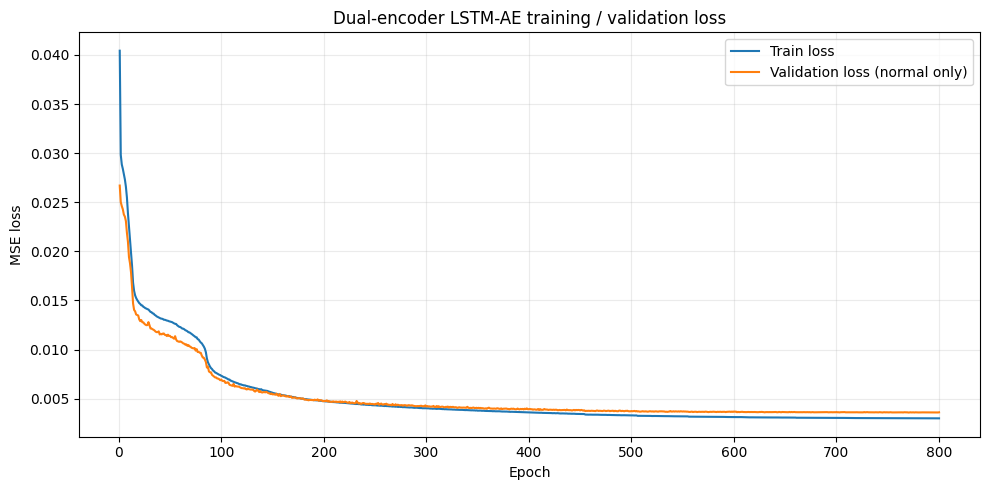

,학습 항목,값
0,seconds,1606.457627
1,epochs_run,800
2,epoch_limit,800
3,early_stopped,False
4,best_val_loss,0.003582
5,minimum_val_loss_epoch,770
6,early_stopping_best_val_loss,0.003588
7,final_weights,last epoch (reference behavior)
8,device,cuda


학습과 정상 validation loss 계산이 오류 없이 완료되었습니다.


In [10]:
trained_model, history, training = train_model(data, cfg, OUTPUT_DIR, device)
display(pd.DataFrame(training.items(), columns=['학습 항목', '값']))
print('학습과 정상 validation loss 계산이 오류 없이 완료되었습니다.')

## 10. 검증 데이터 threshold 선정과 테스트 평가

기준 notebook과 동일하게 각 window의 **마지막 timestep**에서 3채널 평균 reconstruction MSE를 anomaly score로 사용합니다. Threshold는 validation score와 label만으로 `precision == recall`이 처음 성립하는 지점에서 선택합니다. Test score와 label은 선택된 threshold로 최종 평가할 때만 사용합니다.

기준 규칙상 정확히 같은 precision/recall 지점이 없으면 오류를 내고 다른 threshold 규칙으로 임의 대체하지 않습니다.

In [18]:
from sklearn import metrics
import seaborn as sns

def flatten_last_timestep(x):
    """기준 notebook처럼 각 window의 마지막 timestep 3채널만 반환합니다."""
    flattened = np.empty((x.shape[0], x.shape[2]))
    for index in range(x.shape[0]):
        flattened[index] = x[index, x.shape[1] - 1, :]
    return flattened

@torch.inference_mode()
def predict_reconstruction(model, x, device, batch_size=32):
    """기준 predict와 같은 32개 batch 단위 reconstruction 추론입니다."""
    model.eval()
    predictions = []
    for start in range(0, len(x), batch_size):
        batch = torch.tensor(x[start:start + batch_size], dtype=torch.float32, device=device)
        predictions.append(model(batch).cpu().numpy())
    return np.concatenate(predictions, axis=0)

def reconstruction_scores(model, x, device):
    prediction = predict_reconstruction(model, x, device)
    return np.mean(np.power(flatten_last_timestep(x) - flatten_last_timestep(prediction), 2), axis=1)

def select_threshold(y, scores):
    """기준 guidebook의 첫 번째 정확한 precision == recall 규칙을 유지합니다."""
    precision, recall, thresholds = metrics.precision_recall_curve(list(y), scores)
    matches = [i for i, (p, r) in enumerate(zip(precision[:-1], recall[:-1])) if p == r]
    if not matches:
        raise ValueError('기준 규칙에 맞는 정확한 precision == recall threshold가 없습니다. 임의 대체하지 않습니다.')
    index = matches[0]
    return float(thresholds[index]), index, precision, recall, thresholds

def plot_score_distribution(scores, labels, threshold, split, output_dir):
    plt.figure(figsize=(10, 5))
    for label, name, color in [(0, 'Normal', '#4C72B0'), (1, 'Anomaly', '#DD8452')]:
        subset = scores[labels == label]
        if len(subset):
            sns.histplot(subset, bins=40, stat='density', element='step', fill=False,
                         label=f'{name} (n={len(subset)})', color=color)
    plt.axvline(threshold, color='red', linestyle='--', label='Selected threshold')
    plt.xlabel('Last-timestep reconstruction MSE'); plt.ylabel('Density')
    plt.title(f'{split.title()} anomaly-score distribution'); plt.legend(); plt.grid(alpha=.2)
    plt.tight_layout(); plt.savefig(output_dir / f'{split}_score_distribution.png', dpi=140)
    plt.show(); plt.close()

def evaluate_model(model, data, output_dir, manifest, device):
    # 1) Validation으로만 threshold를 선택합니다.
    valid_scores = reconstruction_scores(model, data['X_valid'], device)
    threshold, index, precision, recall, thresholds = select_threshold(data['Y_valid'], valid_scores)
    pd.DataFrame({'threshold': thresholds, 'precision': precision[:-1], 'recall': recall[:-1]}).to_csv(
        output_dir / 'threshold_curve.csv', index=False
    )
    plt.figure(figsize=(10, 6)); visible = thresholds <= .2
    # 기준 notebook의 guide plot 인덱스 shift를 그대로 유지합니다.
    plt.plot(thresholds[visible], precision[1:][visible], label='Precision (guide plot)')
    plt.plot(thresholds[visible], recall[1:][visible], label='Recall (guide plot)')
    plt.plot(threshold, precision[index], 'o', color='red', label='Selected threshold')
    plt.xlabel('Threshold'); plt.ylabel('Precision / Recall'); plt.title('Validation threshold curve')
    plt.legend(); plt.grid(alpha=.2); plt.tight_layout()
    plt.savefig(output_dir / 'threshold_curve.png', dpi=140); plt.show(); plt.close()

    # 2) Test는 고정된 threshold로 한 번만 최종 평가합니다.
    test_scores = reconstruction_scores(model, data['X_test'], device)
    y_test = data['Y_test']; predicted = (test_scores > threshold).astype(int)
    confusion = metrics.confusion_matrix(y_test, predicted, labels=[0, 1])
    valid_predicted = (valid_scores > threshold).astype(int)
    result = {
        'accuracy': metrics.accuracy_score(y_test, predicted),
        'precision': metrics.precision_score(y_test, predicted, zero_division=0),
        'recall': metrics.recall_score(y_test, predicted, zero_division=0),
        'f1': metrics.f1_score(y_test, predicted, zero_division=0),
        'roc_auc': metrics.roc_auc_score(y_test, test_scores),
        'average_precision': metrics.average_precision_score(y_test, test_scores),
        'threshold': threshold, 'confusion_matrix': confusion,
        'fp_count': int(confusion[0, 1]), 'fn_count': int(confusion[1, 0]),
        'normal_false_positive_rate': confusion[0, 1] / confusion[0].sum(),
        'anomaly_miss_rate': confusion[1, 0] / confusion[1].sum(),
        'validation_curve_precision': precision[index], 'validation_curve_recall': recall[index],
        'validation_strict_precision': metrics.precision_score(data['Y_valid'], valid_predicted, zero_division=0),
        'validation_strict_recall': metrics.recall_score(data['Y_valid'], valid_predicted, zero_division=0),
    }
    save_json(output_dir / 'metrics.json', result)

    for split, scores, labels in [('valid', valid_scores, data['Y_valid']), ('test', test_scores, y_test)]:
        rows = manifest[manifest.split == split].copy()
        assert np.array_equal(rows.label.to_numpy(), labels)
        rows['reconstruction_mse'] = scores; rows['predicted_label'] = (scores > threshold).astype(int)
        rows['threshold'] = threshold
        fp = (rows.label == 0) & (rows.predicted_label == 1)
        fn = (rows.label == 1) & (rows.predicted_label == 0)
        rows['outcome'] = np.select([fp, fn], ['FP', 'FN'], default='correct')
        rows.to_csv(output_dir / f'{split}_predictions.csv', index=False, encoding='utf-8-sig')
        rows[fp | fn].to_csv(output_dir / f'{split}_error_cases.csv', index=False, encoding='utf-8-sig')
        print(f'{split}: FP={int(fp.sum())}, FN={int(fn.sum())}')
        plot_score_distribution(scores, labels, threshold, split, output_dir)

    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title('Dual-encoder test confusion matrix'); plt.xlabel('Predicted class'); plt.ylabel('True class')
    plt.tight_layout(); plt.savefig(output_dir / 'confusion_matrix.png', dpi=140); plt.show(); plt.close()
    return result

## 11. 평가 실행

9번의 학습 실행 cell이 성공해 `trained_model`이 만들어진 뒤에만 아래 cell을 실행하세요. 선택된 threshold, confusion matrix, Accuracy·Precision·Recall·F1, FP/FN, validation/test score 분포를 출력하고 결과 폴더에 저장합니다.

평가 결과를 본 뒤에는 threshold, 모델 구조, 학습 hyperparameter를 변경하지 않습니다.

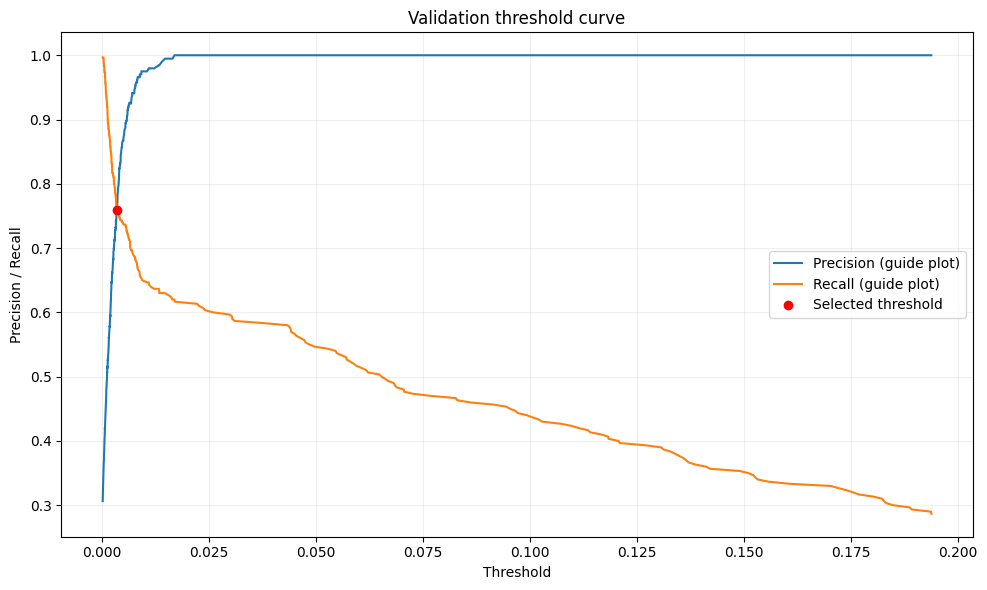

valid: FP=71, FN=72


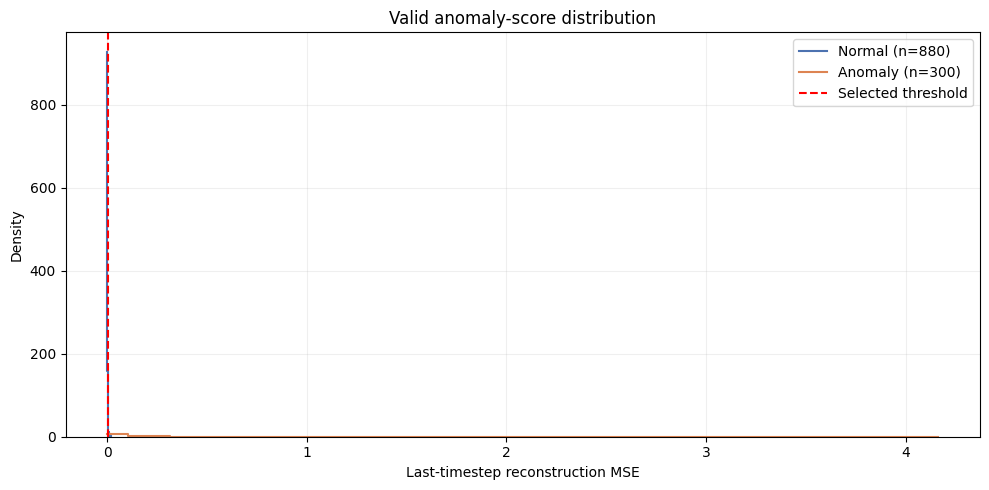

test: FP=103, FN=32


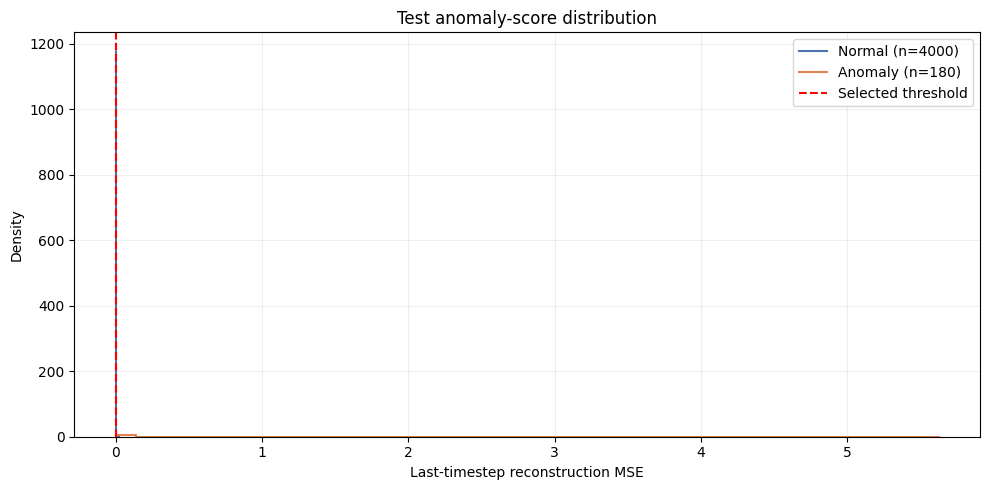

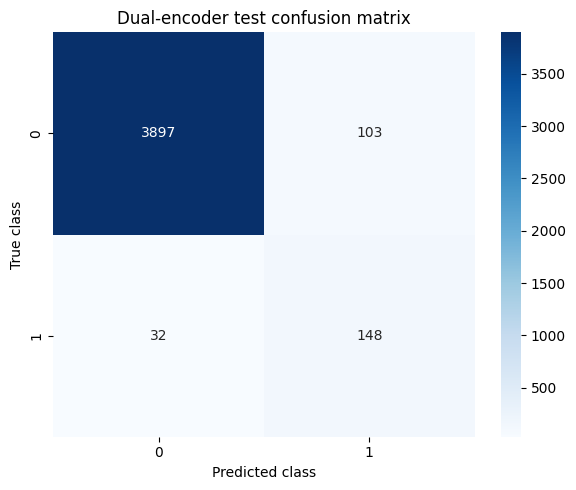

,Metric,Value
0,Threshold,0.003528
1,Accuracy,0.967703
2,Precision,0.589641
3,Recall,0.822222
4,F1,0.686775
5,FP,103.000000
6,FN,32.000000


Test confusion matrix:
[[3897  103]
 [  32  148]]


In [19]:
evaluation = evaluate_model(trained_model, data, OUTPUT_DIR, manifest, device)
display(pd.DataFrame({
    'Metric': ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'FP', 'FN'],
    'Value': [evaluation['threshold'], evaluation['accuracy'], evaluation['precision'],
           evaluation['recall'], evaluation['f1'], evaluation['fp_count'], evaluation['fn_count']],
}))
print('Test confusion matrix:')
print(np.array(evaluation['confusion_matrix']))

## 12. Single-encoder와 dual-encoder 결과 비교

이 비교는 동일한 데이터·split·threshold 규칙에서 별도로 실행한 single-encoder baseline의 `metrics.json`이 있을 때만 수행합니다. Guidebook의 수치를 baseline 실행 결과처럼 자동 사용하지 않습니다.

아래 `BASELINE_METRICS_PATH`를 실제 baseline 결과의 `metrics.json` 경로로 지정한 뒤 실행하세요. Baseline과 dual-encoder 모두 test 평가를 마친 뒤에는 결과를 보고 threshold·구조·학습 hyperparameter를 변경하지 않습니다.

In [20]:
# 예시: PROJECT_ROOT / 'baseline_results' / 'run01' / 'metrics.json'
# 실제 single-encoder 실행 결과 파일을 지정하세요. None인 상태에서는 비교를 실행하지 않습니다.
BASELINE_METRICS_PATH = None
BASELINE_MODEL_LABEL = 'Single-encoder LSTM-AE'
DUAL_MODEL_LABEL = 'Dual-encoder sensor-fusion LSTM-AE'

def load_baseline_metrics(metrics_path):
    if metrics_path is None:
        raise FileNotFoundError(
            'BASELINE_METRICS_PATH가 None입니다. 동일 조건으로 실행한 single-encoder의 metrics.json 경로를 지정하세요.'
        )
    metrics_path = Path(metrics_path)
    if not metrics_path.is_file():
        raise FileNotFoundError(f'Baseline metrics.json을 찾을 수 없습니다: {metrics_path}')
    baseline = json.loads(metrics_path.read_text(encoding='utf-8'))
    required = {'accuracy', 'precision', 'recall', 'f1', 'threshold', 'confusion_matrix'}
    missing = required.difference(baseline)
    if missing:
        raise ValueError(f'Baseline metrics.json에 필수 항목이 없습니다: {sorted(missing)}')
    matrix = np.asarray(baseline['confusion_matrix'])
    if matrix.shape != (2, 2):
        raise ValueError(f'Baseline confusion_matrix는 (2, 2)여야 합니다: {matrix.shape}')
    return baseline

def compare_models(baseline, dual, output_dir):
    baseline_cm = np.asarray(baseline['confusion_matrix'])
    dual_cm = np.asarray(dual['confusion_matrix'])
    baseline_values = {
        'Trainable parameters': int(baseline.get('trainable_parameters', 63171)),
        'Threshold': baseline['threshold'], 'Accuracy': baseline['accuracy'],
        'Precision': baseline['precision'], 'Recall': baseline['recall'], 'F1': baseline['f1'],
        'FP': int(baseline_cm[0, 1]), 'FN': int(baseline_cm[1, 0]),
    }
    dual_values = {
        'Trainable parameters': int(parameter_counts(trained_model)['trainable_parameters']),
        'Threshold': dual['threshold'], 'Accuracy': dual['accuracy'],
        'Precision': dual['precision'], 'Recall': dual['recall'], 'F1': dual['f1'],
        'FP': int(dual_cm[0, 1]), 'FN': int(dual_cm[1, 0]),
    }
    comparison = pd.DataFrame({BASELINE_MODEL_LABEL: baseline_values, DUAL_MODEL_LABEL: dual_values})
    comparison['Difference (dual - baseline)'] = comparison[DUAL_MODEL_LABEL] - comparison[BASELINE_MODEL_LABEL]
    comparison.to_csv(output_dir / 'model_comparison.csv', encoding='utf-8-sig')
    save_json(output_dir / 'model_comparison.json', {
        'baseline_metrics_path': str(Path(BASELINE_METRICS_PATH).resolve()),
        'baseline': baseline_values, 'dual_encoder': dual_values,
    })

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for axis, matrix, title in [
        (axes[0], baseline_cm, BASELINE_MODEL_LABEL),
        (axes[1], dual_cm, DUAL_MODEL_LABEL),
    ]:
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=[0, 1], yticklabels=[0, 1], ax=axis)
        axis.set(title=title, xlabel='예측 class', ylabel='실제 class')
    plt.tight_layout()
    plt.savefig(output_dir / 'model_comparison_confusion_matrix.png', dpi=140)
    plt.show()
    plt.close()
    return comparison


## 13. 비교표 생성

11번 평가 실행까지 끝낸 뒤, `BASELINE_METRICS_PATH`를 지정하고 이 cell을 실행하세요. Difference는 `dual - baseline`입니다. 값의 차이는 이번 데이터·split·seed·설정에 한정해 해석하며, 일반적 우수성으로 주장하지 않습니다.

In [14]:
baseline_evaluation = load_baseline_metrics(BASELINE_METRICS_PATH)
comparison = compare_models(baseline_evaluation, evaluation, OUTPUT_DIR)
display(comparison)

FileNotFoundError: BASELINE_METRICS_PATH가 None입니다. 동일 조건으로 실행한 single-encoder의 metrics.json 경로를 지정하세요.